In [57]:
import numpy as np
import random as rand
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
import os
import json
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
models_path = os.path.join(project_root, "Models")
sys.path.append(models_path)
from ELO import Elo
from tqdm import tqdm

In [58]:
# Get project root (2 levels up from current notebook location)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
 
# Define key directories
models_dir = os.path.join(project_root, 'Models')
trained_models_dir = os.path.join(project_root, 'Trained_Models')
simulated_data_dir = os.path.join(project_root, 'Simulated_Data')
results_dir = os.path.join(project_root, 'Results')
 
# Add Models to Python path
if models_dir not in sys.path:
    sys.path.insert(0, models_dir)
 
# Verify paths exist
print("=" * 60)
print("PROJECT PATHS VERIFICATION")
print("=" * 60)
print(f"Project Root:      {project_root}")
print(f"Models Dir:        {models_dir} ✓" if os.path.exists(models_dir) else f"Models Dir:        {models_dir} ✗")
print(f"Trained Models:    {trained_models_dir} ✓" if os.path.exists(trained_models_dir) else f"Trained Models:    {trained_models_dir} ✗")
print(f"Simulated Data:    {simulated_data_dir} ✓" if os.path.exists(simulated_data_dir) else f"Simulated Data:    {simulated_data_dir} ✗")
print(f"Results Dir:       {results_dir} ✓" if os.path.exists(results_dir) else f"Results Dir:       {results_dir} ✗")
print("=" * 60)

PROJECT PATHS VERIFICATION
Project Root:      /Users/GraceCeline/Bachelorarbeit
Models Dir:        /Users/GraceCeline/Bachelorarbeit/Models ✓
Trained Models:    /Users/GraceCeline/Bachelorarbeit/Trained_Models ✓
Simulated Data:    /Users/GraceCeline/Bachelorarbeit/Simulated_Data ✓
Results Dir:       /Users/GraceCeline/Bachelorarbeit/Results ✓


In [59]:
def load_testing_data(scenario, split):
    base_path = os.path.join(project_root, 'Simulated_Data')
    
    filename = f"scenario_{scenario}_{split}_data.csv"
    filepath = os.path.join(base_path, filename)
    
    return pd.read_csv(filepath)

In [60]:
def construct_training_data(df, initial_id, last_id, num_task):
    X = []
    Y = []

    task_ids    = sorted(df['task'].unique())
    task_to_idx = {task: idx for idx, task in enumerate(task_ids)}

    for student_id in range(initial_id, last_id):
        student_df = df[df['student_id'] == student_id].reset_index(drop=True)
        X_student = [torch.zeros(num_task * 2)] 
        Y_student = []

        for _, row in student_df.iterrows():
            task_id = row['task']
            success = row['success']
            y_student = torch.tensor([int(task_id), float(success)])
            Y_student.append(y_student)

            x_student = torch.zeros(num_task *2)
            if success == 1:
                x_student[task_id] = 1
            else:
                x_student[task_id + num_task] = 1
            X_student.append(x_student)
        
        X_student = torch.stack(X_student)
        Y_student = torch.stack(Y_student)
        X.append(X_student)
        Y.append(Y_student)

    return X, Y


In [61]:
import torch
import random

class DKT(torch.nn.Module):
    def __init__(self, num_exercises, num_neurons = 32, C = 1000., num_epochs = 5000, learning_rate = 1E-2):
        super(DKT, self).__init__()
        self.num_exercises_ = num_exercises
        self.num_neurons_   = num_neurons
        self.C_             = C
        self.num_epochs_    = num_epochs
        self.learning_rate_ = learning_rate
        self.gru_           = torch.nn.GRU(self.num_exercises_ * 2, self.num_neurons_) # this is f
        self.out_           = torch.nn.Linear(self.num_neurons_, self.num_exercises_) # this is g

    def forward(self, X):
        H, _ = self.gru_(X)
        return self.out_(H)

    """
    Scores the accuracy of this model.
    """
    def score(self, X, Y):
        num_attempts  = 0
        num_successes = 0
        for i in range(len(X)):
            Yi = Y[i]
            Logits = self.forward(X[i])
            selected_logits = Logits.gather(
                                  1, Yi[:,0].long().unsqueeze(1)
                              ).squeeze(1)
            probs = torch.sigmoid(selected_logits)
            preds = (probs >= 0.5).float()

            num_successes += (preds == Yi[:,1]).sum().item()
            num_attempts += len(Yi[:,1])
        return num_successes / num_attempts

    """
    Fits this model to the given data matrix.

    Parameters
    ----------
    X: list
        A list of feature matrices, one per student.
    Y: list
        A list of target matrices, one per student.

    """
    def fit(self, X, Y):
        # initialize optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate_, weight_decay = 1. / self.C_)
        self.train()
        # start training
        for epoch in range(self.num_epochs_):
            # re-set the current gradient to zero
            optimizer.zero_grad()
            # get a random student index
            i  = random.randrange(len(X))
            Xi = X[i]
            Yi = Y[i]
            # compute the Logits
            Logits = self.forward(Xi)
            selected_logits = Logits.gather(
                                  1, Yi[:,0].long().unsqueeze(1)
                              ).squeeze(1) # Choose the index of the executed task, and only take the logit of this task for every time step
            # compute the loss
            loss = torch.nn.functional.binary_cross_entropy_with_logits(selected_logits, Yi[:,1].float())
            # report the loss
            if (epoch+1) % 1000 == 0:
                print('epoch %d: loss %g' % (epoch+1, loss.item()))
            # compute the gradient
            loss.backward()
            # apply the optimizer
            optimizer.step()

        return self

In [62]:
def load_model(scenario_id, num_exercises, base_dir=None, device=None):
    """
    Load a saved DKT model checkpoint for testing.

    Args:
        scenario_id : scenario identifier (e.g. 1–6, or a string name)
        base_dir    : optional override for the Trained_Models folder path
        device      : torch.device to load onto ('cpu', 'cuda', etc.)
                      defaults to cuda if available, else cpu

    Returns:
        model       : DKT model in eval() mode, ready for inference
        checkpoint  : full checkpoint dict (contains hyperparams if needed)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if base_dir is None:
        base_dir = os.path.join(project_root, 'Trained_Models')

    model_path = os.path.join(base_dir, f'DKT_model_scenario_{scenario_id}.pth')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"No saved model found for scenario {scenario_id} at:\n  {model_path}")

    checkpoint = torch.load(model_path, map_location=device)

    # Rebuild the architecture from saved constructor args
    model = DKT(
        num_exercises = num_exercises,
        num_neurons   = checkpoint['num_neurons'],
        C             = checkpoint['C'],
        num_epochs    = checkpoint['num_epochs'],
        learning_rate = checkpoint['learning_rate'],
    )

    # Load the trained weights
    model.load_state_dict(checkpoint['model_state'])
    model.to(device)
    model.eval() # Set model to evaluation mode

    return model, checkpoint

In [63]:
def skill_display(optimal_skills):
    x_values = list(range(1, len(optimal_skills) + 1))
    # Convert data for plotting: organize skill levels into separate lists for each skill
    paired_lists = [
        [optimal_skills[j][i] for j in range(len(optimal_skills))]
        for i in range(len(optimal_skills[0]))
        ]
    num_lines = len(paired_lists) # Number of skills to plot
    colors = plt.cm.viridis(np.linspace(0, 1, num_lines)) # Generate a color palette
    plt.figure(figsize=(8, 4))
    plt.title("Highest learning gain")
    # Plot each skill level over time
    for i in range(num_lines):
        plt.plot(paired_lists[i], linestyle='-', color=colors[i], label=f'Skill {i+1}')

    plt.xlabel('Time')
    plt.ylabel('Skill Level')
    plt.legend()
    plt.grid(True)
    plt.show()

In [64]:
def calculate_p_op(n):
    return 0.5 - 1 / (2 * (n - 1))
    # Let n be the ratio of k_success and k_fail

In [91]:
def steps_to_mastery(X, Y, dkt_model, initial_skill, q_matrix, difficulty, depends, k_success, k_fail, p_op): 
    results_dkt = [] 
    DKT_Data = [] 
    
    for i in range(len(X)): 
        skill_levels = initial_skill.copy() # reset per student 
        X_student = torch.zeros((1, num_tasks * 2), dtype=torch.float32) 
        reached_step = None 
        step = 0 
        data_for_student = [] 
        skill_history = [initial_skill.tolist()] 
        
        while np.any(skill_levels <= 1.5) and step < 30: # ← safety cap 
            step += 1 
            with torch.no_grad(): 
                prob = torch.sigmoid(dkt_model(X_student))[-1] 
            uncertainty = torch.abs(prob - p_op) 
            task = torch.argmin(uncertainty).item() 
            updated_skill, correctness = Elo.skill_update( difficulty[task], skill_levels, q_matrix[:, task], depends, k_success, k_fail ) 
            skill_levels = updated_skill 
            skill_history.append(skill_levels.tolist()) 
            data_for_student.append((task, correctness)) 
            new_row = torch.zeros((1, num_tasks * 2), dtype=torch.float32) 
            if correctness == 1: 
                    new_row[0, task] = 1.0 
            else: 
                    new_row[0, task + num_tasks] = 1.0 
            X_student = torch.cat([X_student, new_row]) 
            
            if reached_step is None and np.all(skill_levels >= 1.5): 
                reached_step = step 
                
        results_dkt.append({ "student": i + 1, "steps_to_mastery": reached_step}) 
        DKT_Data.append(data_for_student) 
        last_skill_history = skill_history 
    average_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].mean() 
    skill_history_array = np.array(last_skill_history) 
    return average_steps, skill_history_array

In [98]:
def run_unoptimized(p_op=0.5):
            results = []
            average_step_lower_p_op, rand_plot_lower_p_op = steps_to_mastery(X_test, Y_test, dkt, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 0.1, p_op) # pop 0
            average_step_normal_p_op, rand_plot_normal_p_op  = steps_to_mastery(X_test, Y_test, dkt, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 0.25, p_op)
            average_step_higher_p_op, rand_plot_higher_p_op = steps_to_mastery(X_test, Y_test, dkt, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 0.5, p_op)
                
            results.append({
                                "scenario":            scenario_id,
                                "avg_steps_0.1":       average_step_lower_p_op,
                                "avg_steps_0.25":       average_step_normal_p_op,
                                "avg_steps_0.5":       average_step_higher_p_op,
            })
                        
            results_table = pd.DataFrame(results)
        
            steps      = range(rand_plot_higher_p_op.shape[0])

            print(f"PLOT FOR p_op = {p_op}")
            print(results_table)


            fig, axes = plt.subplots(1, 3, figsize=(16, 5))

            data = [(rand_plot_lower_p_op, f'k- = 0.1', 'o'),
                    (rand_plot_normal_p_op, f'k- = 0.25', 's'),
                    (rand_plot_higher_p_op, f'k- = 0.5', '^')]
            
            colors = [('blue', 'blue'), ('orange', 'green'), ('purple', 'brown')]
            
            for ax, (rand_plot, title, marker), (c1, c2) in zip(axes, data, colors):
                steps = range(rand_plot.shape[0])
                ax.plot(steps, rand_plot[:, 0], marker=marker, label='Skill 1', linewidth=2, color=c1)
                ax.plot(steps, rand_plot[:, 1], marker=marker, label='Skill 2', linewidth=2, color=c2)
                ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5)
                ax.set_title(title, fontweight='bold')
                ax.set_xlabel('Step')
                ax.set_ylabel('Skill Level')
                ax.legend()
                ax.grid(True, alpha=0.3)
            
            fig.suptitle(f'Skill Mastery Progression — Scenario {scenario_id}', fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()

In [93]:
def optimized_steps_to_mastery(X, Y, dkt_model, num_tasks, initial_skill, q_matrix, difficulty, depends, k_success, n): # n is ratio from k+ to k-
    results_dkt      = []
    DKT_Data         = []
    k_fail = 1/n
    p_op = calculate_p_op(n)
    print(f"Adjusted kappa with k- being {k_fail}")

    for i in range(len(X)):
        skill_levels     = initial_skill.copy()   # reset per student
        X_student        = torch.zeros((1, num_tasks * 2), dtype=torch.float32)
        reached_step     = None
        step             = 0
        data_for_student = []
        skill_history    = [initial_skill.tolist()]

        while np.any(skill_levels <= 1.5) and step < 30:  # ← safety cap
            step += 1

            with torch.no_grad():
                prob      = torch.sigmoid(dkt_model(X_student))[-1]
            uncertainty   = torch.abs(prob - p_op)
            task          = torch.argmin(uncertainty).item()

            updated_skill, correctness = Elo.skill_update(
                difficulty[task], skill_levels, q_matrix[:, task], depends, k_success, k_fail
            )
            skill_levels = updated_skill
            skill_history.append(skill_levels.tolist())
            data_for_student.append((task, correctness))

            new_row = torch.zeros((1, num_tasks * 2), dtype=torch.float32)
            if correctness == 1:
                new_row[0, task] = 1.0
            else:
                new_row[0, task + num_tasks] = 1.0
            X_student = torch.cat([X_student, new_row])

            if reached_step is None and np.all(skill_levels >= 1.5):
                reached_step = step

        results_dkt.append({
            "student":           i + 1,
            "steps_to_mastery":  reached_step,
            "p_op":         p_op
        })
        DKT_Data.append(data_for_student)
        last_skill_history = skill_history

    average_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].mean()
    skill_history_array = np.array(last_skill_history)
    return average_steps, skill_history_array, p_op

In [94]:
def run_optimization(num_tasks):
            results = []
            average_step_lower_p_op, rand_plot_lower_p_op, p_op_2 = optimized_steps_to_mastery(X_test, Y_test, dkt, num_tasks, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 2) # pop 0
            average_step_normal_p_op, rand_plot_normal_p_op, p_op_4  = optimized_steps_to_mastery(X_test, Y_test, dkt, num_tasks, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 4)
            average_step_higher_p_op, rand_plot_higher_p_op, p_op_6 = optimized_steps_to_mastery(X_test, Y_test, dkt,  num_tasks,init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 6)
        
            results.append({
                        "scenario":            scenario_id,
                        "avg_steps_0.0":       average_step_lower_p_op,
                        "avg_steps_0.25":       average_step_normal_p_op,
                        "avg_steps_0.4":       average_step_higher_p_op,
                })
                
            results_table = pd.DataFrame(results)
            print(results_table)

            steps      = range(rand_plot_higher_p_op.shape[0])

            fig, axes = plt.subplots(1, 3, figsize=(16, 5))

            data = [(rand_plot_lower_p_op, 'p_op = 0.0', 'o'),
                    (rand_plot_normal_p_op, 'p_op = 0.25', 's'),
                    (rand_plot_higher_p_op, 'p_op = 0.4', '^')]
            
            colors = [('blue', 'blue'), ('orange', 'green'), ('purple', 'brown')]
            
            for ax, (rand_plot, title, marker), (c1, c2) in zip(axes, data, colors):
                steps = range(rand_plot.shape[0])
                ax.plot(steps, rand_plot[:, 0], marker=marker, label='Skill 1', linewidth=2, color=c1)
                ax.plot(steps, rand_plot[:, 1], marker=marker, label='Skill 2', linewidth=2, color=c2)
                ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5)
                ax.set_title(title, fontweight='bold')
                ax.set_xlabel('Step')
                ax.set_ylabel('Skill Level')
                ax.legend()
                ax.grid(True, alpha=0.3)
            
            fig.suptitle(f'Skill Mastery Progression — Scenario {scenario_id}', fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()

# Optimize DKT

In [95]:
with open('../../elo_variable.json', 'r') as Elo_Data:
    elo_data = json.load(Elo_Data)

print(elo_data)

{'globals': {'students': 500, 'init_skill_level': [0.0, 0.0], 'k_success': 1, 'k_fail': 0.5}, 'scenarios': [{'id': 1, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 0], [0, 1]], 'difficulty_level': [1, 1], 'depends': [-1, -1]}, {'id': 2, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 1], [1, 1]], 'difficulty_level': [0, 1], 'depends': [-1, -1]}, {'id': 3, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0], [0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1], 'depends': [-1, -1, -1, -1]}, {'id': 4, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1], [0, 1, 1, 1]], 'difficulty_level': [1, 1, 0, 1], 'depends': [-1, -1, -1, -1]}, {'id': 5, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1, 0, 1], [0, 1, 1, 0, 1, 1]], 'difficulty_level': [0, 0, 0, 1, 1, 1], 'depends': [-1, -1, -1, -1, -1, -1]}, {'id': 6, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0, 1, 0], [0, 1, 0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1, 2, 2], 'depends': [-1, -1, -1, -1, -1, -1]}

In [96]:
all_data = {}

level_skill   = [] 
mastery_level = 1.5
i = 0

global_values = elo_data["globals"]
scenarios = elo_data["scenarios"]

students          = global_values["students"]
init_skill_level  = np.array(global_values["init_skill_level"])
k_success         = global_values["k_success"]
k_fail            = global_values["k_fail"]

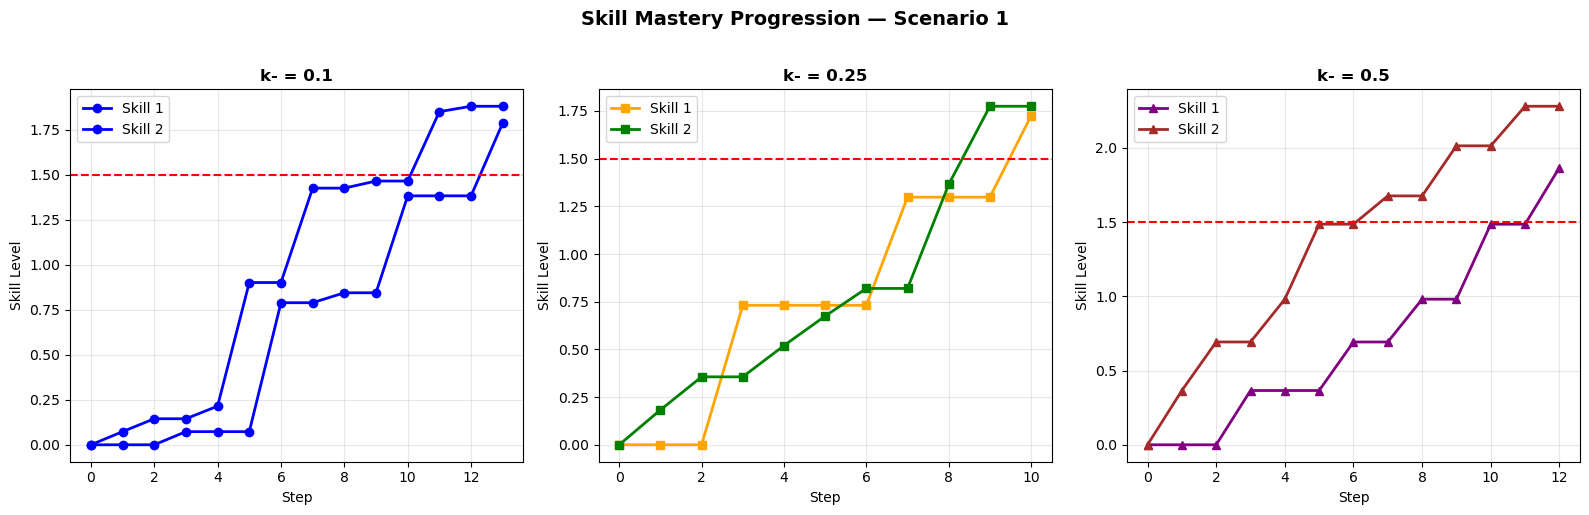

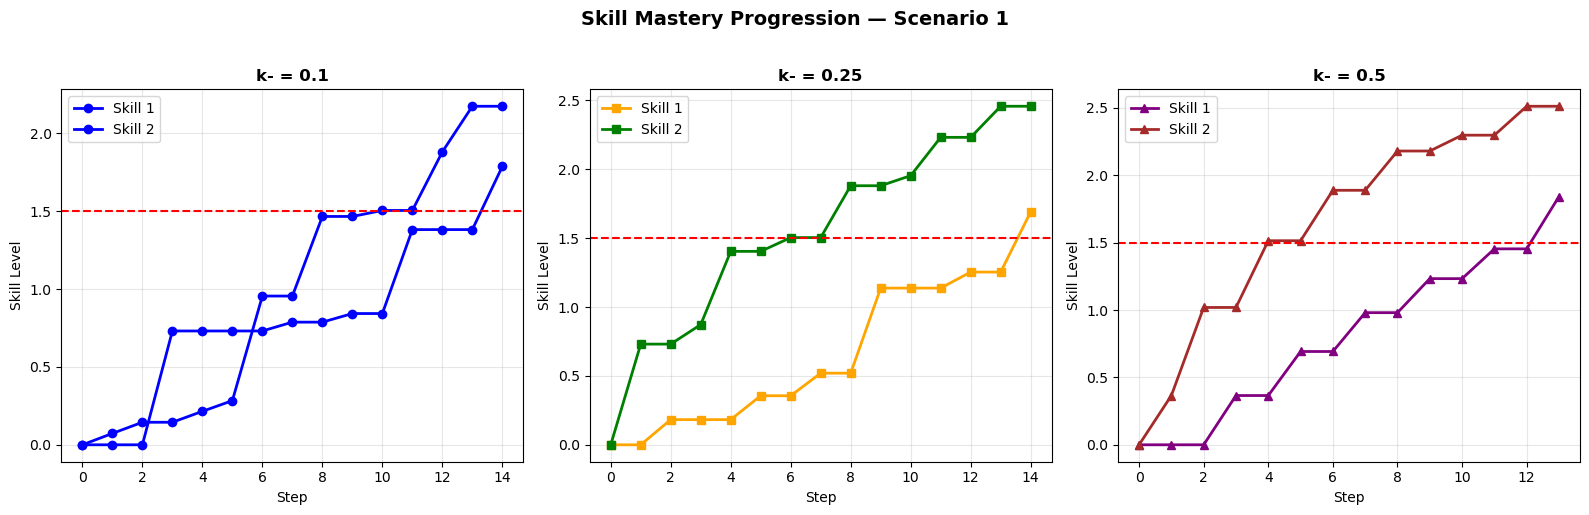

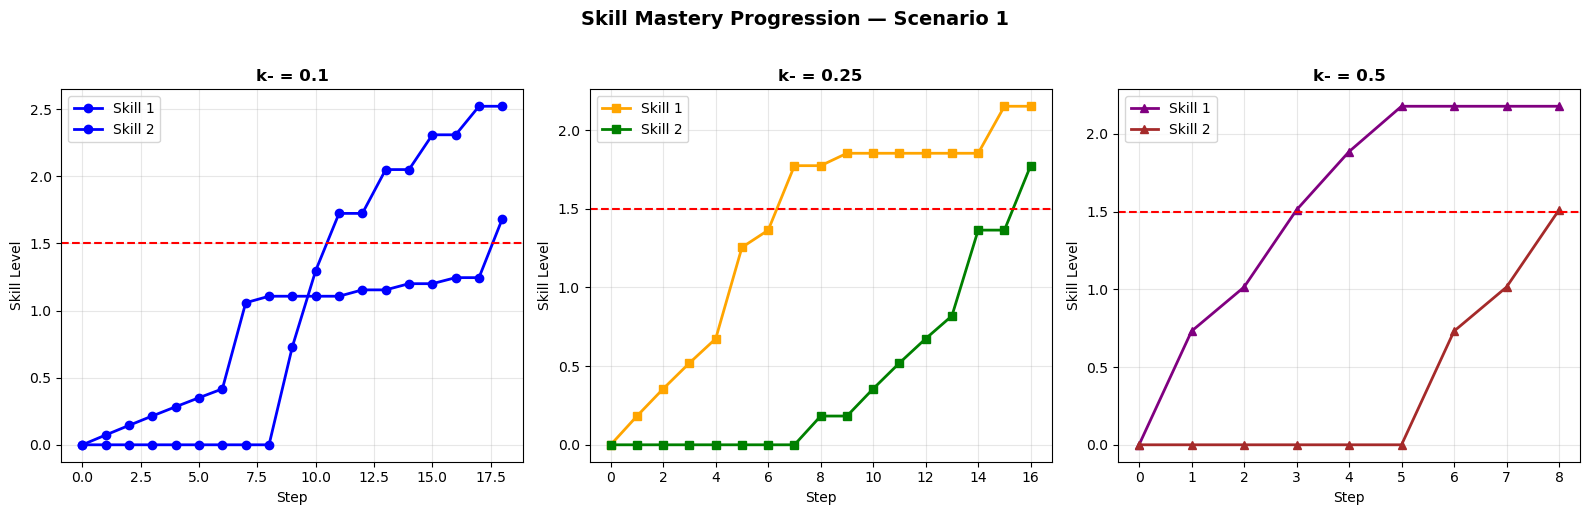

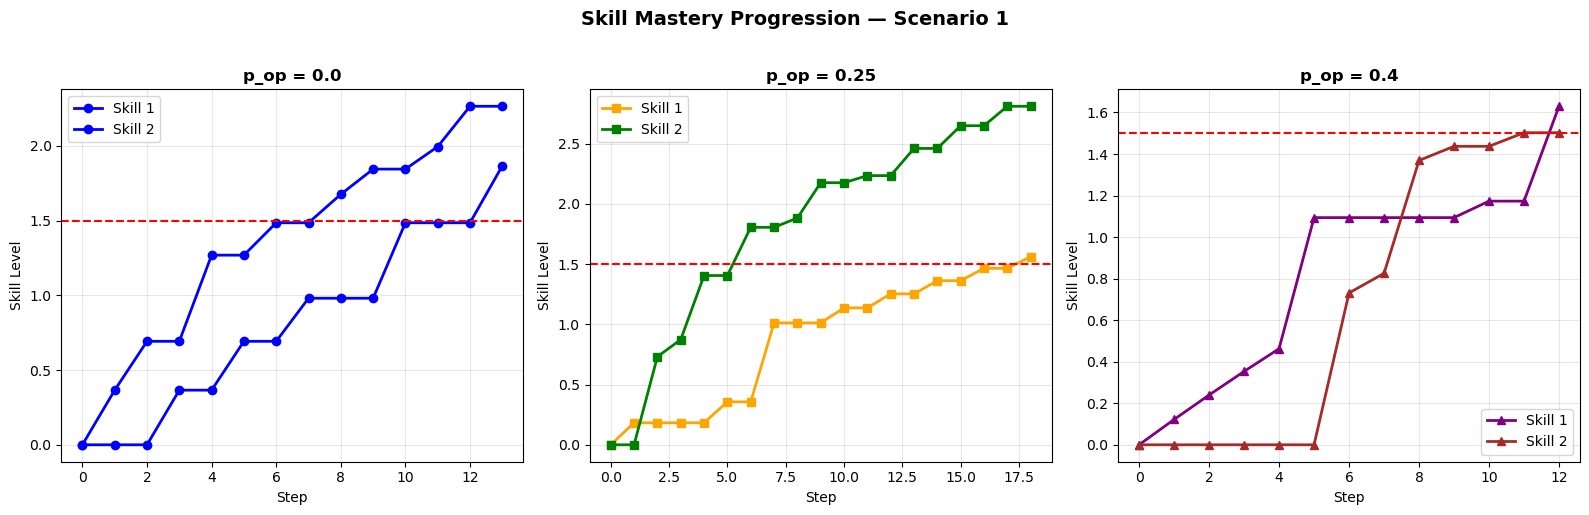

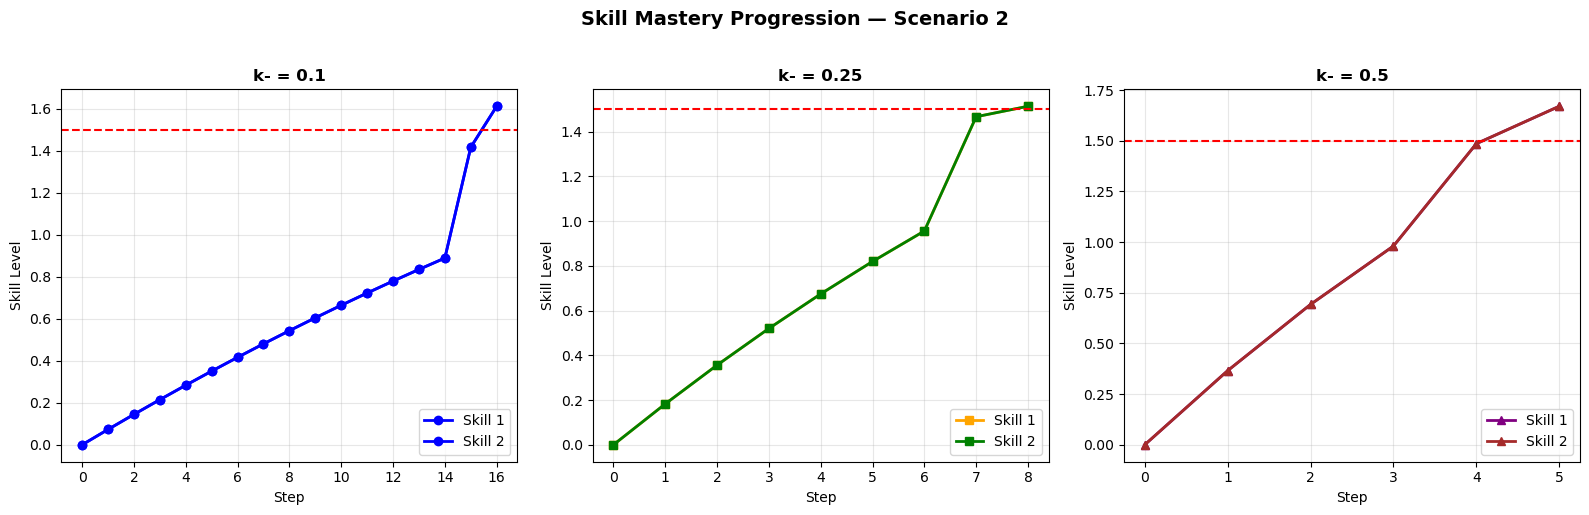

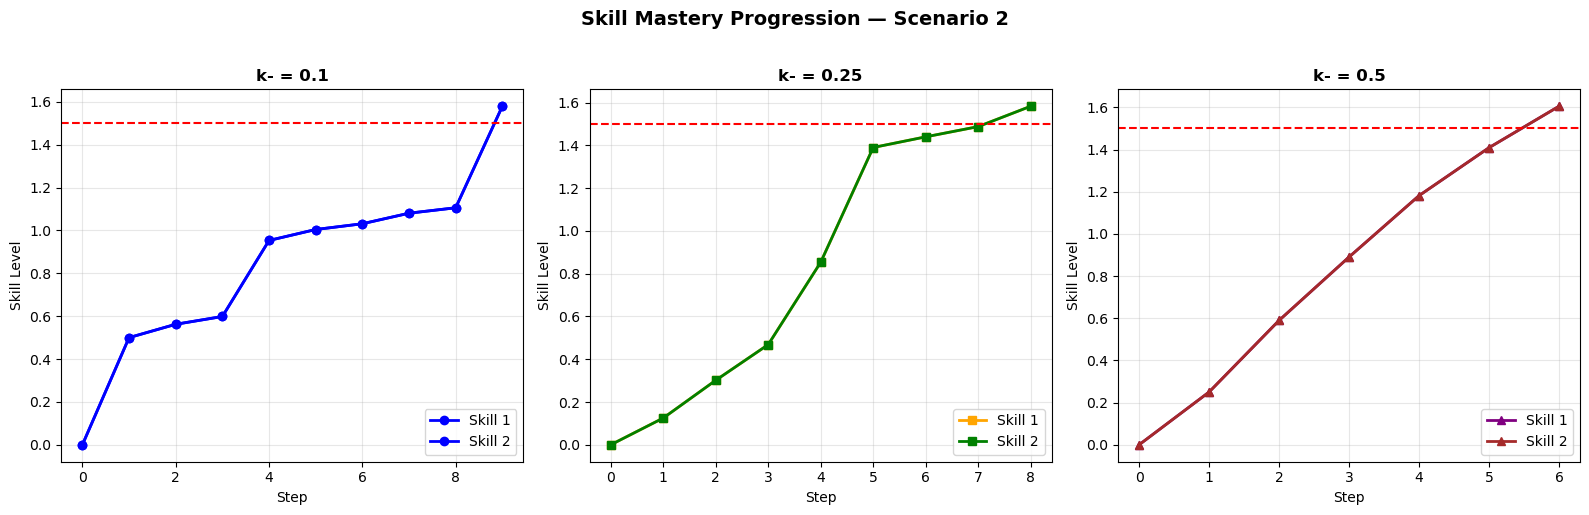

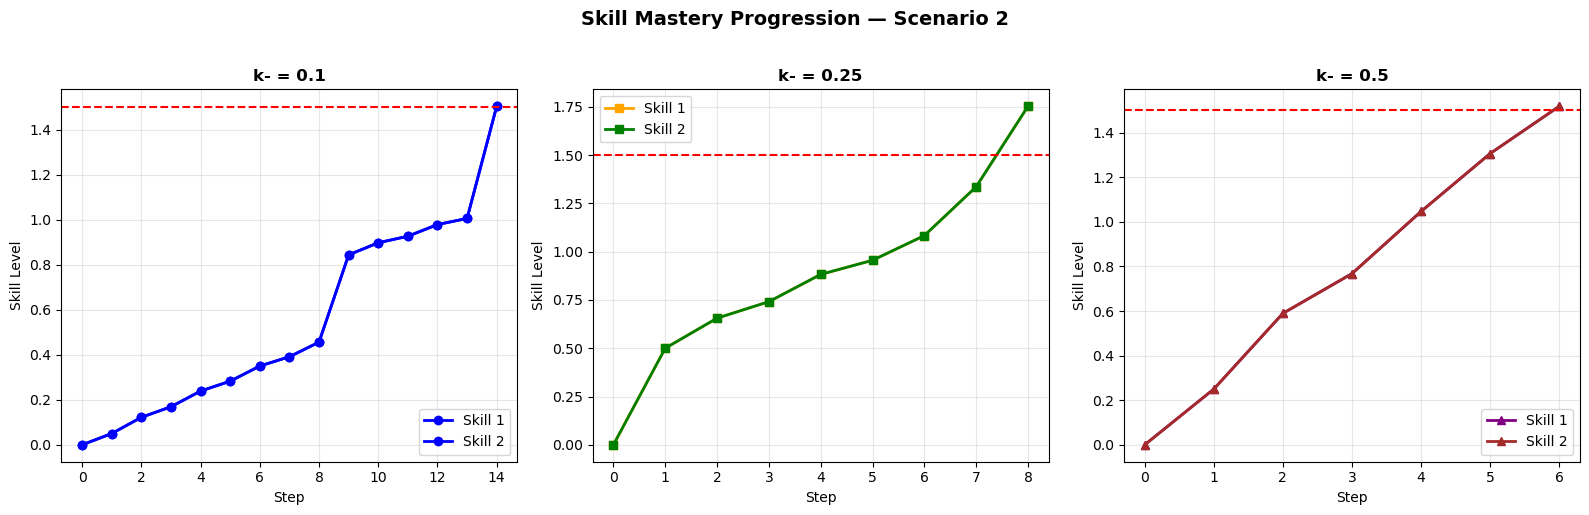

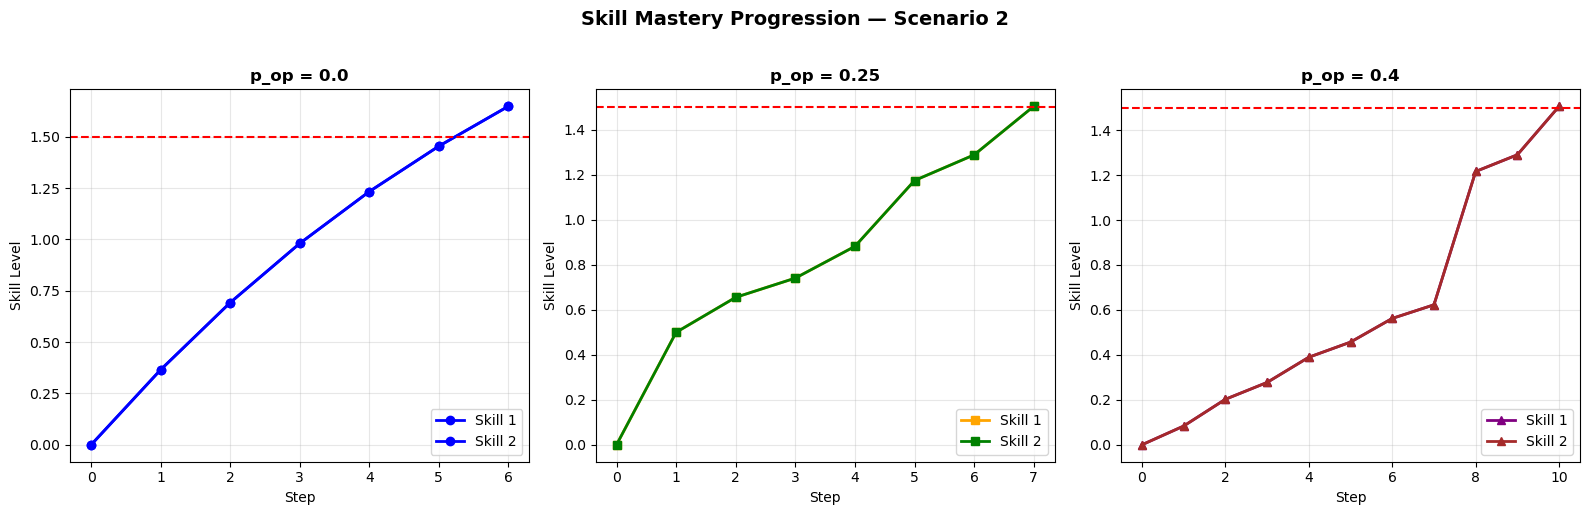

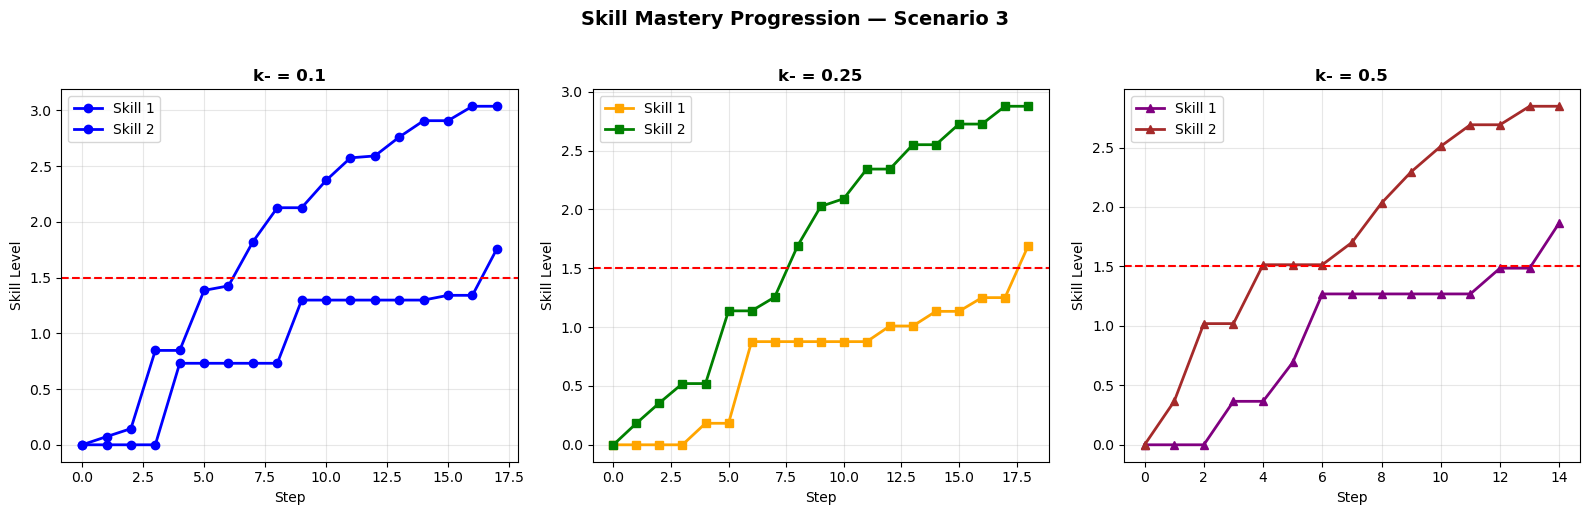

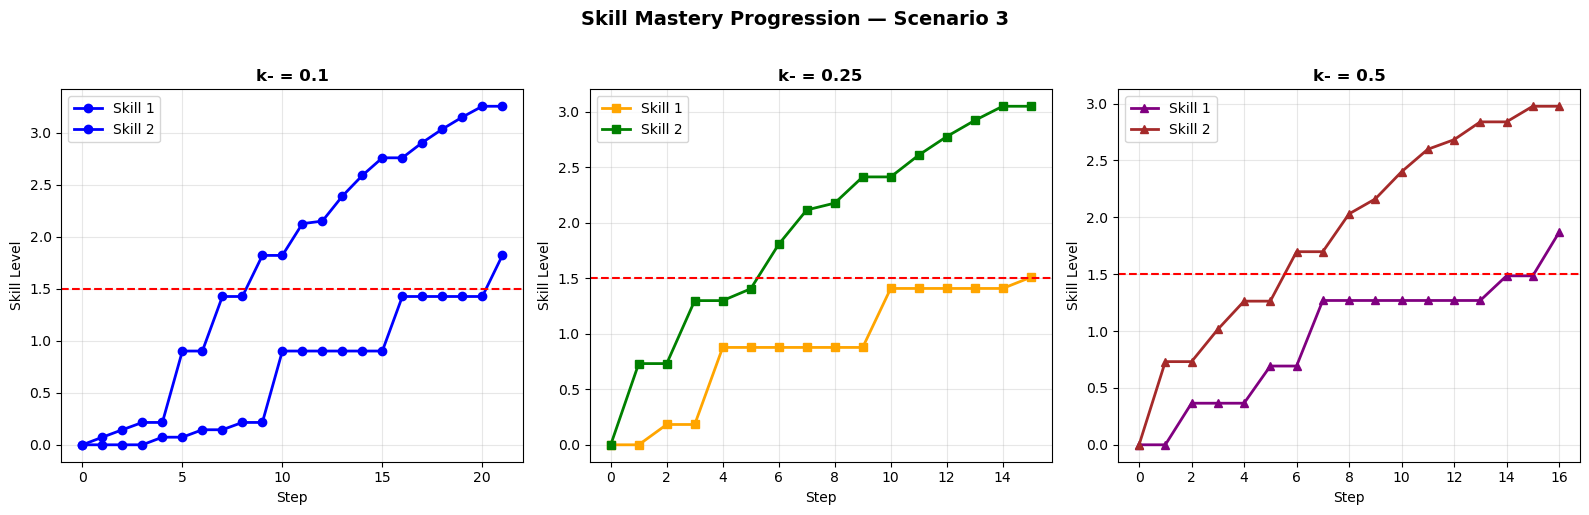

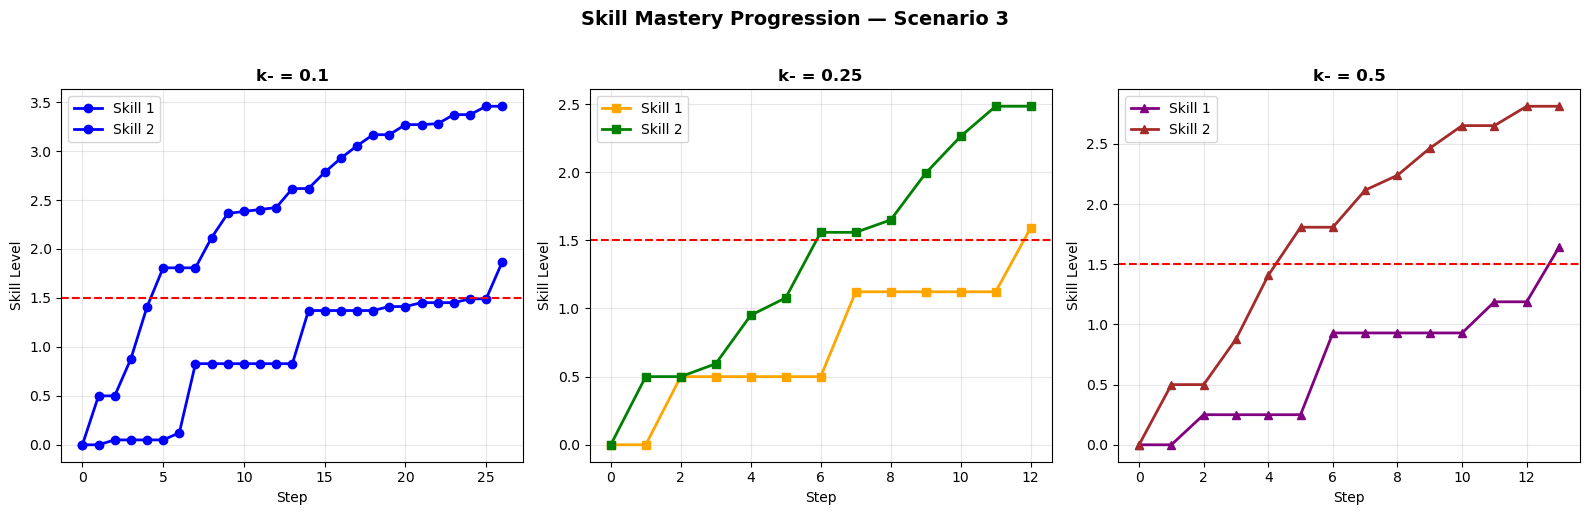

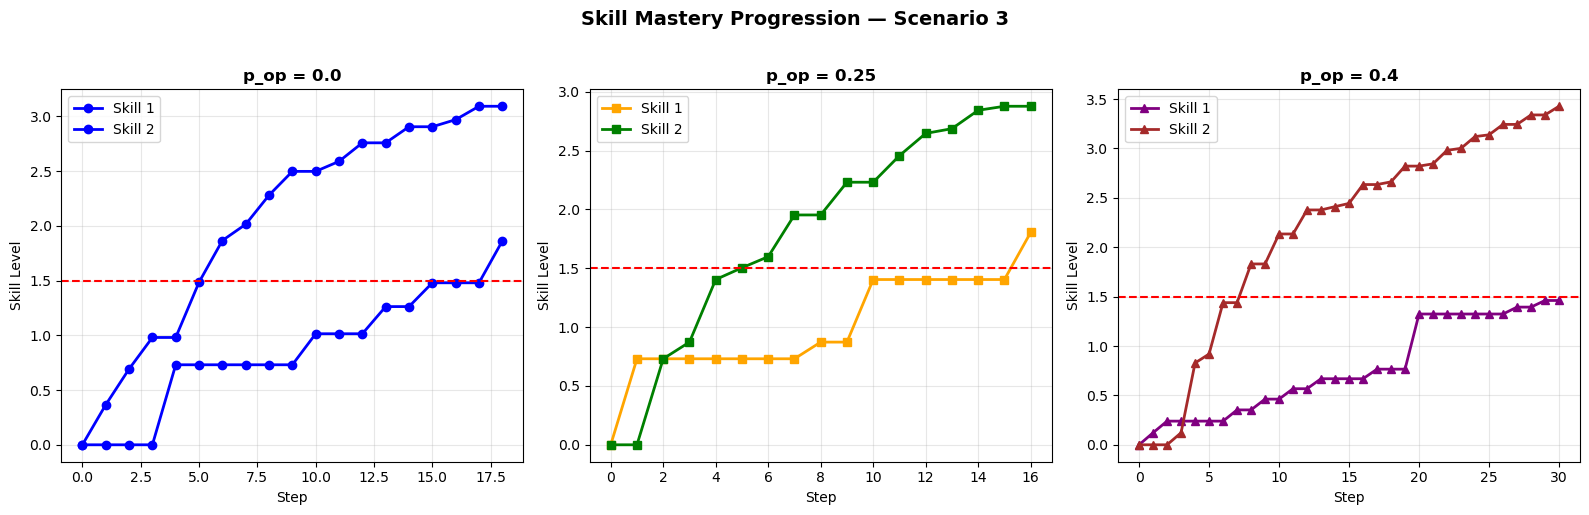

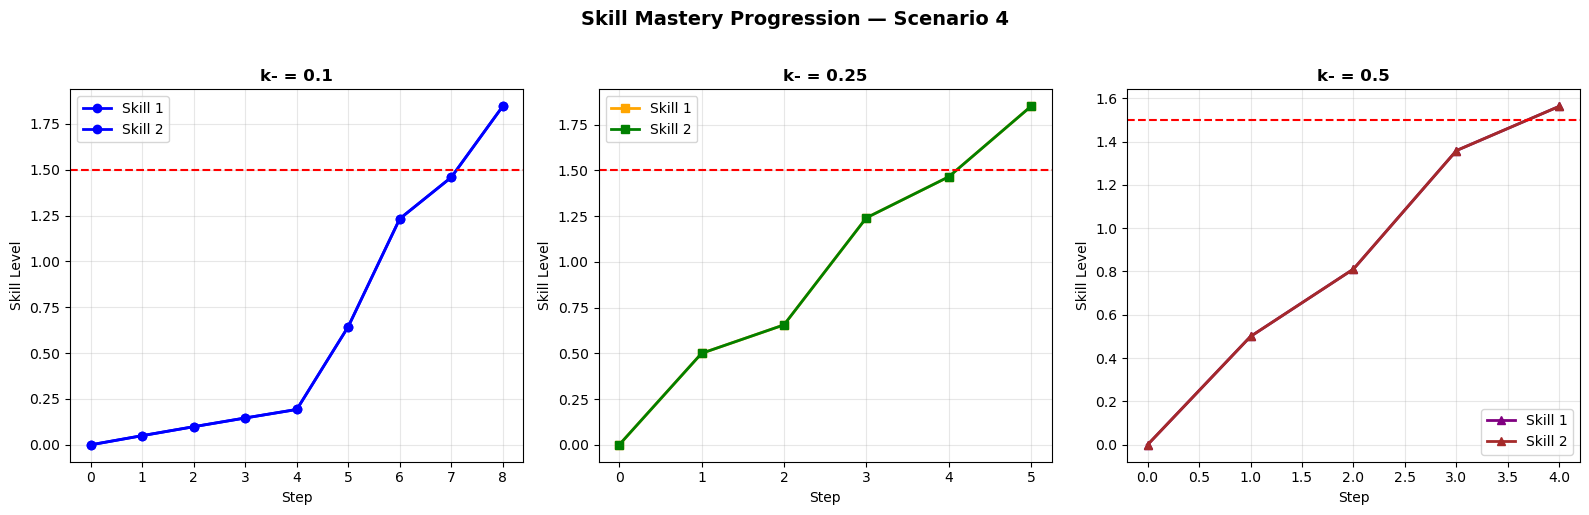

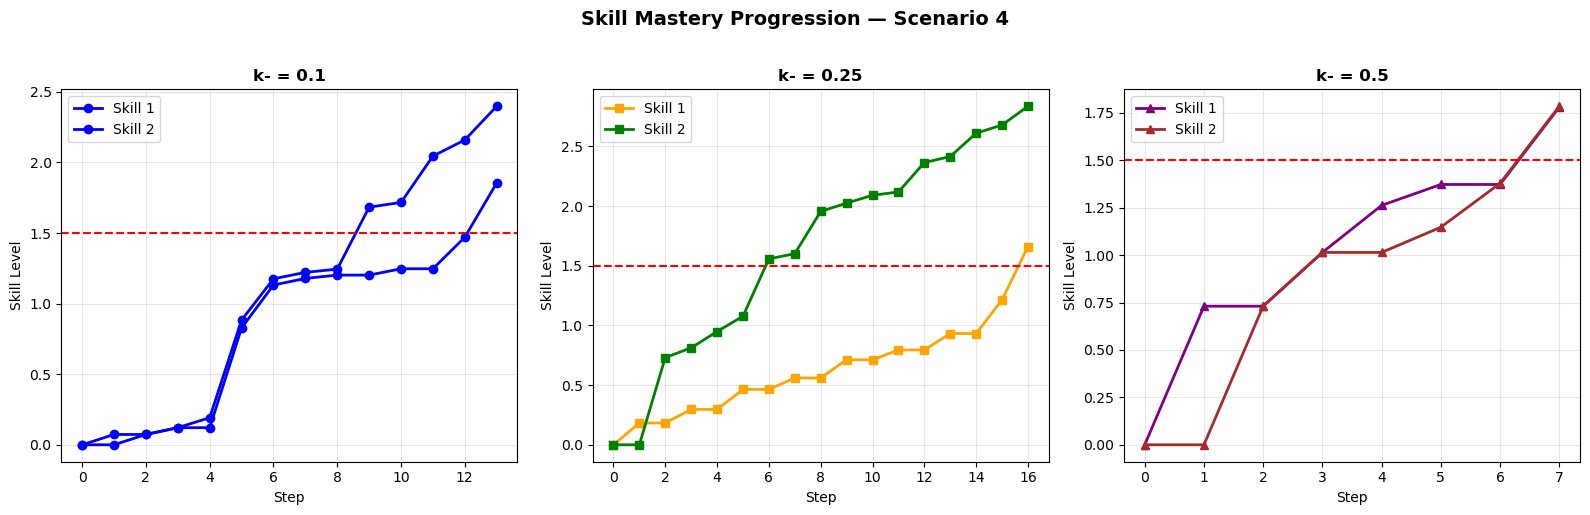

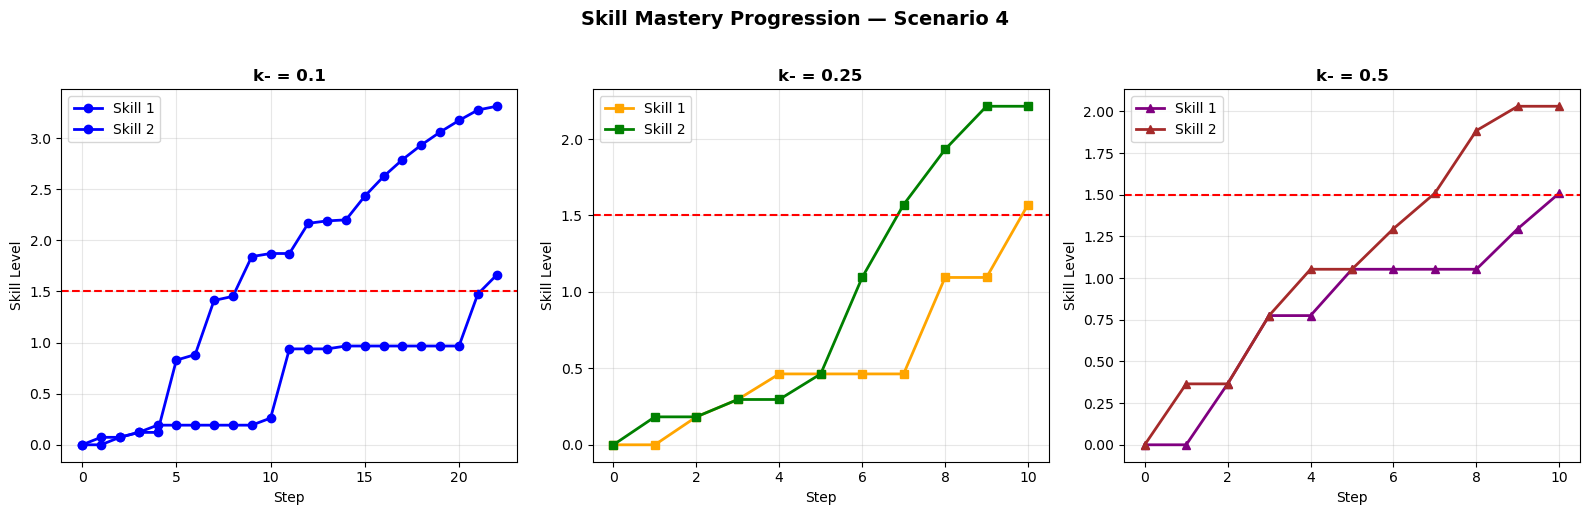

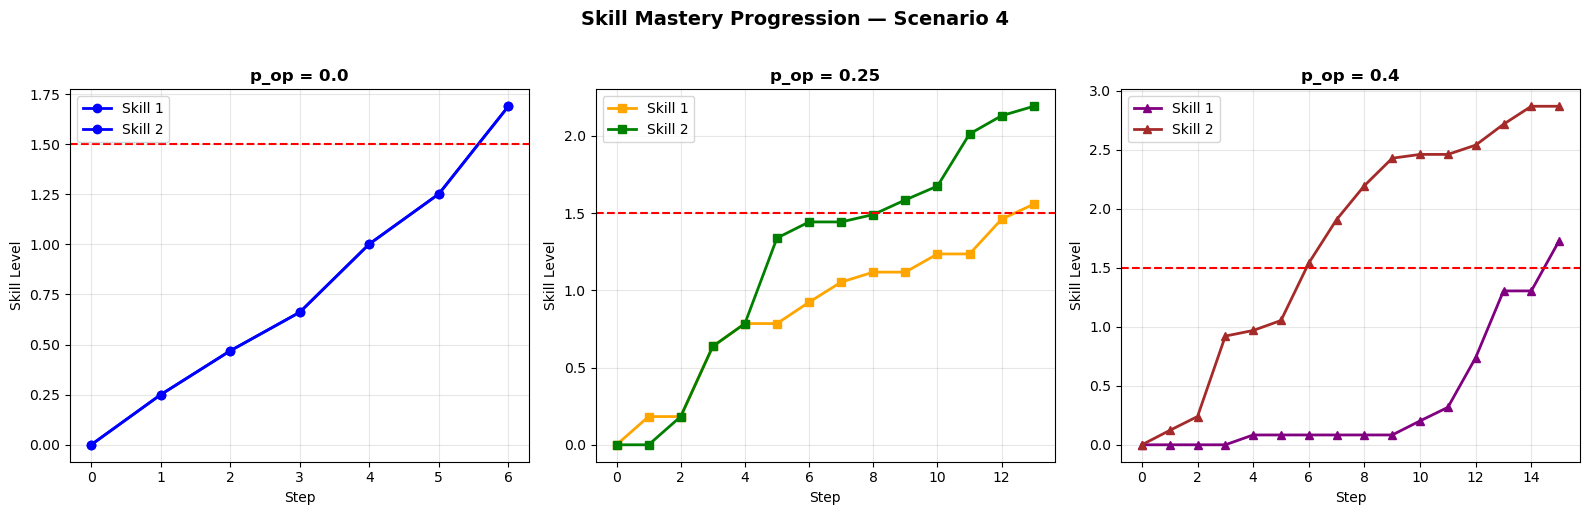

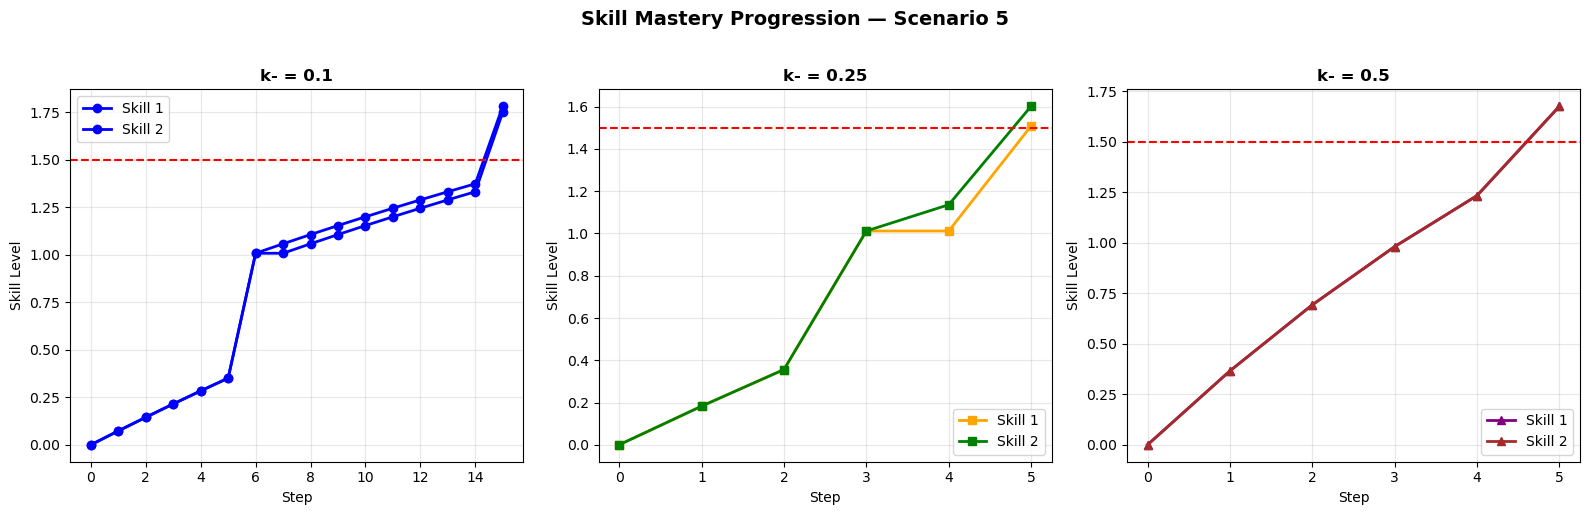

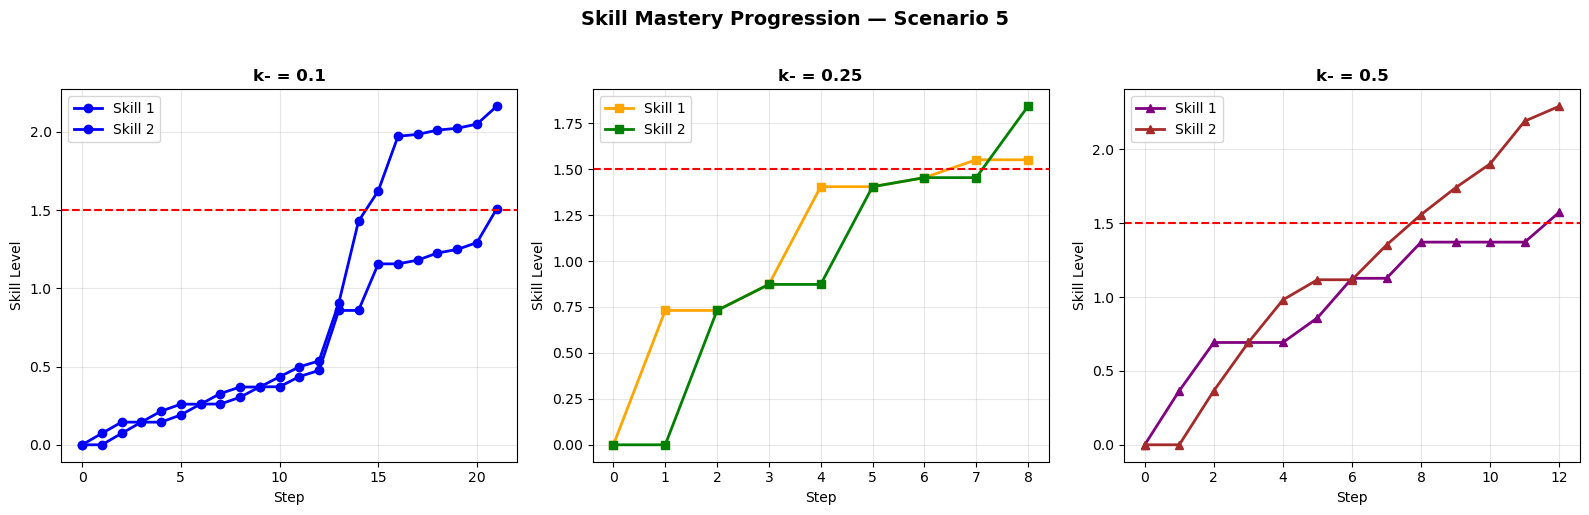

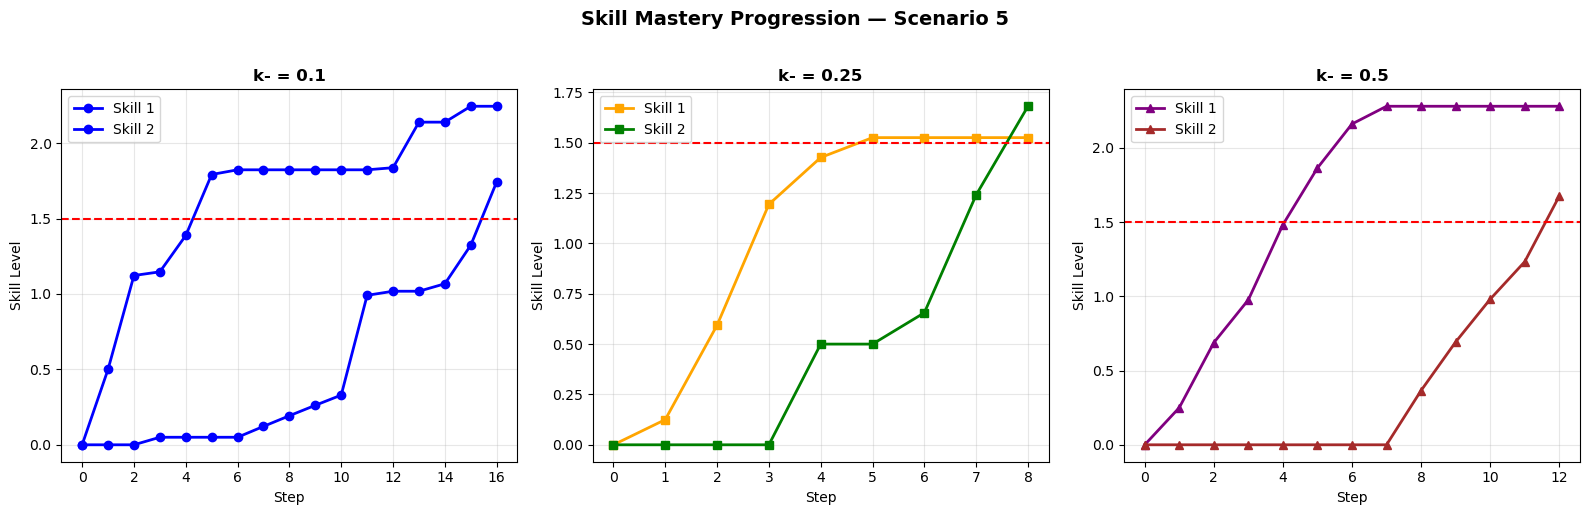

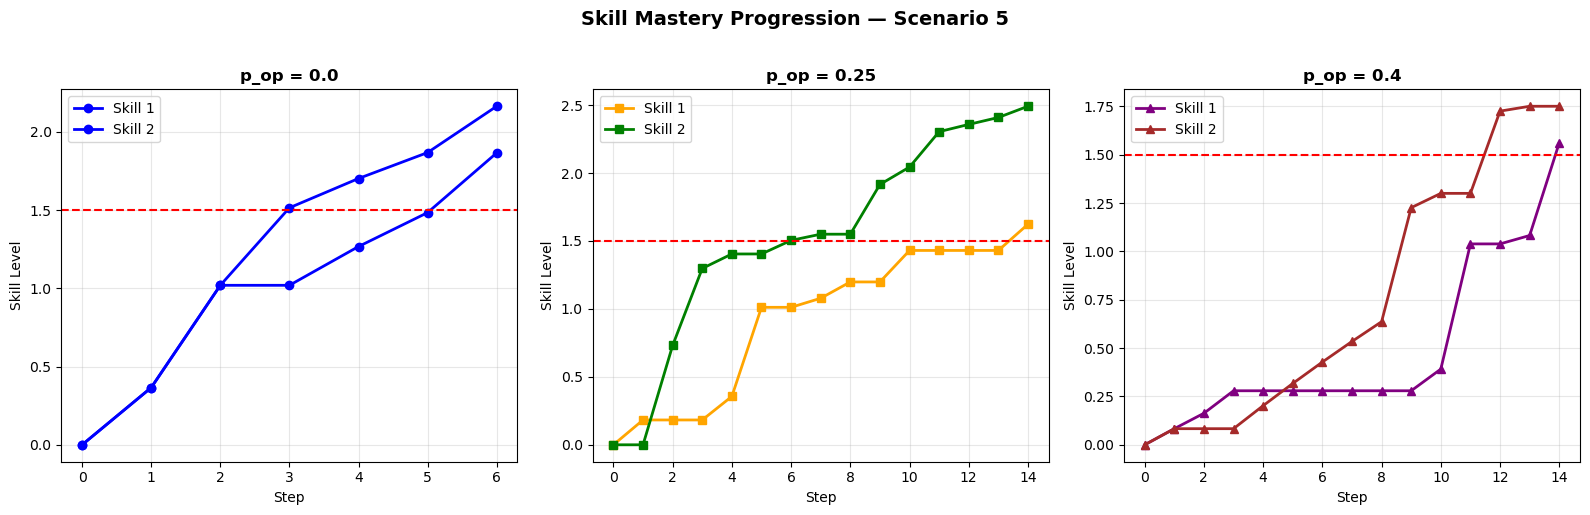

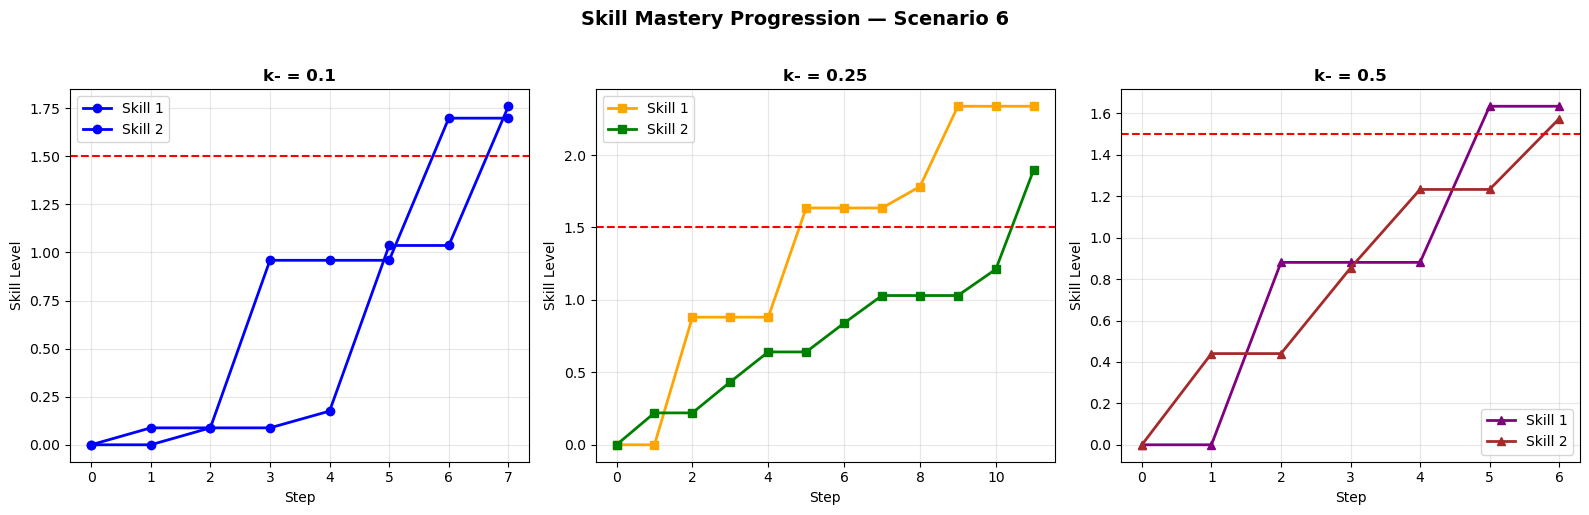

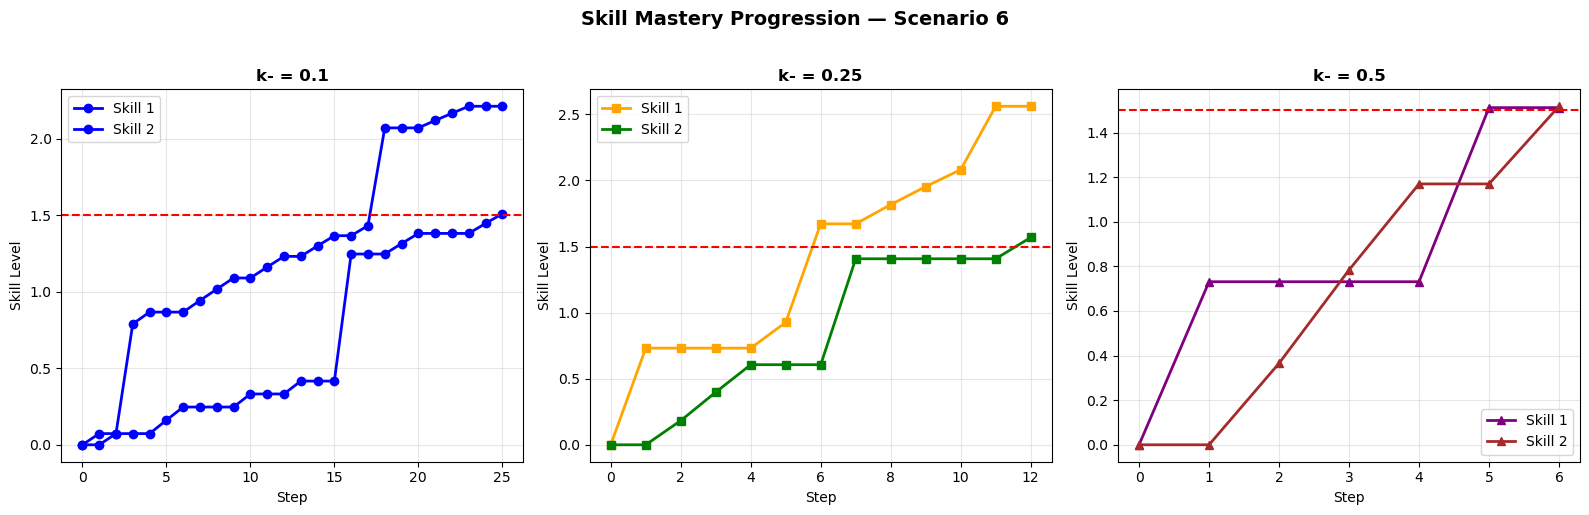

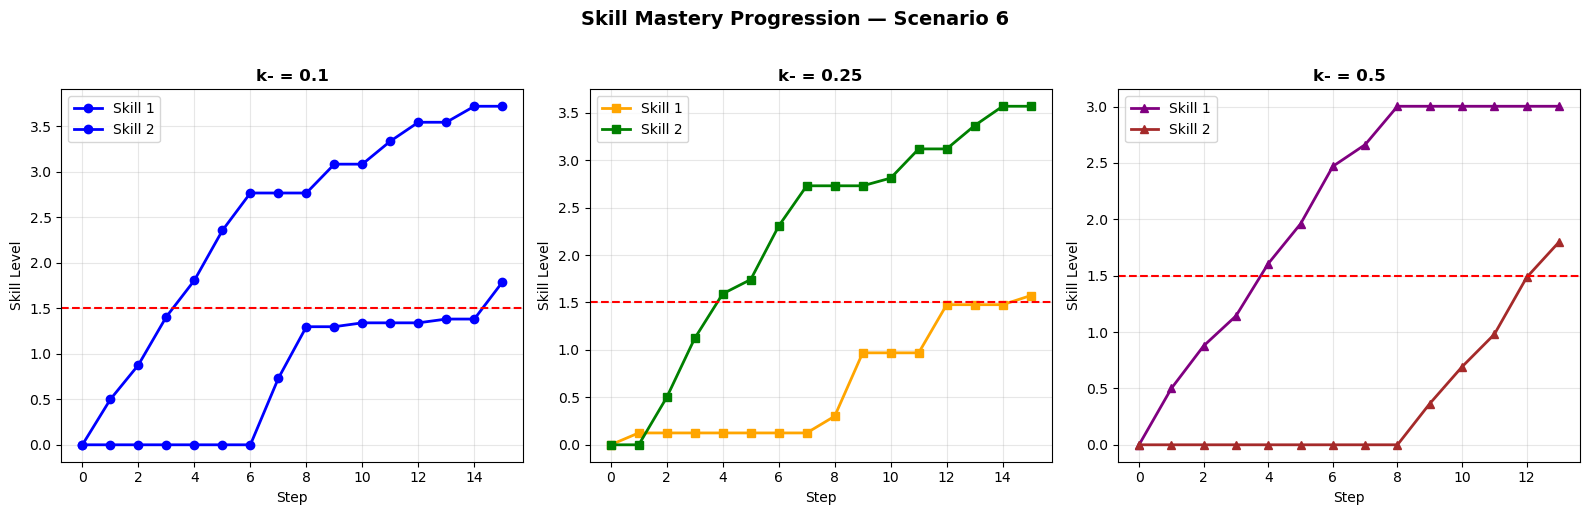

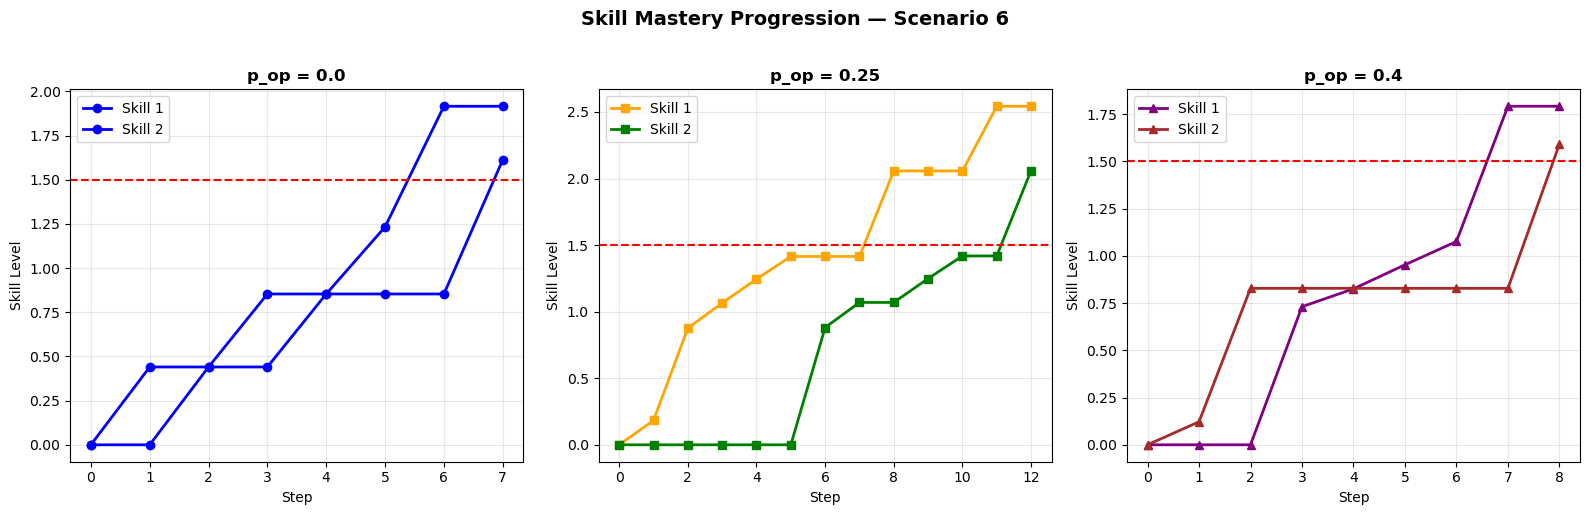

In [97]:
import sys
from io import StringIO

old_stdout = sys.stdout
sys.stdout = StringIO()

for scenario in scenarios:
        scenario_id    = scenario["id"]
        num_tasks      = scenario["num_tasks"]
        difficulty_level = np.array(scenario["difficulty_level"])
        q_matrix       = np.array(scenario["q_matrix"])
        depends = np.array(scenario["depends"])
        
        dkt, checkpoint = load_model(scenario_id, num_tasks)
            
        all_students_skill_dkt = []
        all_students_task_allocation_dkt = []
        
        print(f"-------------- RESULTS FOR SCENARIO {scenario_id}------------------")
        
        num_students_test = 50
        # test_df = load_testing_data(scenario_id, "test")
        # X_test, Y_test   = construct_training_data(test_df, 401, 450, num_tasks)
        run_unoptimized(0)
        run_unoptimized(0.3)
        run_unoptimized()
        print("OPTIMIZE TASK SELECTION METHOD")
        run_optimization(num_tasks)

output = sys.stdout.getvalue()
sys.stdout = old_stdout

with open('results_dkt.txt', 'w') as f:
    f.write(output)
# Your code here - all output will be saved to the file

In [82]:
%%capture jupyter notebook

UsageError: %%capture is a cell magic, but the cell body is empty.
